# BTC Hourly Movement Analysis

## Research Question

Do BTCUSDT movement events occur more frequently during certain UTC hours between 2021 and 2025?

A movement event is defined as an hourly candle range equal to at least 60% of the previous candle's Bollinger Band width.

## Market and Settings

- Market: BTCUSDT
- Interval: 1 hour
- Time zone: UTC
- Period: 2021-01-01 to 2025-12-31
- Bollinger Band length: 20
- Basis: SMA
- Source: Close
- Standard-deviation multiplier: 2.0
- Movement threshold: 0.60

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def is_valid_project_folder(folder: Path) -> bool:
    """
    Check whether a folder has the expected Level 1
    project structure.
    """

    required_paths = [
        folder / "data" / "processed",
        folder / "reports",
        folder / "src",
        folder / "README.md",
    ]

    return all(
        path.exists()
        for path in required_paths
    )


def find_project_folder() -> Path:
    """
    Find the real projectlevel1 folder by checking both
    its name and its expected folder structure.
    """

    current_folder = Path.cwd().resolve()

    search_folders = [
        current_folder,
        *current_folder.parents,
    ]

    for folder in search_folders:
        if (
            folder.name == "projectlevel1"
            and is_valid_project_folder(folder)
        ):
            return folder

        nested_project = folder / "projectlevel1"

        if is_valid_project_folder(nested_project):
            return nested_project

    raise FileNotFoundError(
        "Could not locate a valid projectlevel1 folder."
    )


PROJECT_FOLDER = find_project_folder()

FEATURE_FILE = (
    PROJECT_FOLDER
    / "data"
    / "processed"
    / "btcusdt_1h_features.csv"
)

REPORT_FOLDER = (
    PROJECT_FOLDER
    / "reports"
)

FIGURE_FOLDER = (
    REPORT_FOLDER
    / "figures"
)

print("Project folder:")
print(PROJECT_FOLDER)

print("\nFeature file:")
print(FEATURE_FILE)

print("\nFeature file exists:")
print(FEATURE_FILE.exists())

Project folder:
C:\projects\project\projectlevel1

Feature file:
C:\projects\project\projectlevel1\data\processed\btcusdt_1h_features.csv

Feature file exists:
True


## Load the Feature Dataset

This dataset contains the cleaned hourly candles, Bollinger Band features, movement ratios, movement-event labels, UTC-hour values, and data-gap flags created by the project scripts.

The notebook uses the gap-safe observations for the primary analysis.

In [2]:
def convert_boolean_column(
    series: pd.Series,
) -> pd.Series:
    """
    Convert CSV boolean values into actual Python booleans.
    """

    if series.dtype == bool:
        return series

    return (
        series
        .astype(str)
        .str.strip()
        .str.lower()
        .map(
            {
                "true": True,
                "false": False,
                "1": True,
                "0": False,
            }
        )
        .fillna(False)
        .astype(bool)
    )


df = pd.read_csv(
    FEATURE_FILE
)

df["open_time"] = pd.to_datetime(
    df["open_time"],
    format="ISO8601",
    utc=True,
)

numeric_columns = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "utc_hour",
    "year",
    "movement_ratio",
    "movement_event",
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce",
    )

df["gap_safe_movement_row"] = (
    convert_boolean_column(
        df["gap_safe_movement_row"]
    )
)

analysis_df = df.loc[
    df["gap_safe_movement_row"]
    & df["movement_ratio"].notna()
    & df["movement_event"].notna()
].copy()

analysis_df["movement_event"] = (
    analysis_df["movement_event"]
    .astype(int)
)

analysis_df["utc_hour"] = (
    analysis_df["utc_hour"]
    .astype(int)
)

analysis_df["year"] = (
    analysis_df["year"]
    .astype(int)
)

print("Complete feature dataset:")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}")

print("\nPrimary gap-safe analysis dataset:")
print(f"Rows: {len(analysis_df):,}")

print("\nTime range:")
print(analysis_df["open_time"].min())
print("to")
print(analysis_df["open_time"].max())

print("\nMovement events:")
print(f"{analysis_df['movement_event'].sum():,}")

print("\nOverall movement-event rate:")
print(
    f"{analysis_df['movement_event'].mean() * 100:.2f}%"
)

analysis_df.head()

Complete feature dataset:
Rows: 43,807
Columns: 41

Primary gap-safe analysis dataset:
Rows: 43,647

Time range:
2021-01-01 20:00:00+00:00
to
2025-12-31 23:00:00+00:00

Movement events:
3,998

Overall movement-event rate:
9.16%


,open_time,open,high,low,close,volume,close_time,quote_volume,number_of_trades,taker_buy_base_volume,...,previous_bb_gap_safe,valid_movement_row,movement_ratio,movement_event,movement_gap_affected,gap_safe_movement_row,strict_gap_affected,strict_gap_safe_movement_row,utc_hour,year
20,2021-01-01 20:00:00+00:00,29029.04,29279.72,28880.37,29200.96,1838.549082,2021-01-01 20:59:59.999000+00:00,5.359010e+07,52949,960.228963,...,True,True,0.794077,1,False,True,False,True,20,2021
21,2021-01-01 21:00:00+00:00,29200.97,29289.82,29130.00,29160.39,1447.229641,2021-01-01 21:59:59.999000+00:00,4.228536e+07,34181,776.324093,...,True,True,0.342430,0,False,True,False,True,21,2021
22,2021-01-01 22:00:00+00:00,29163.17,29326.74,29104.57,29262.32,1127.035897,2021-01-01 22:59:59.999000+00:00,3.297228e+07,37533,552.485855,...,True,True,0.516247,0,False,True,False,True,22,2021
23,2021-01-01 23:00:00+00:00,29262.32,29338.89,29228.14,29331.69,971.123385,2021-01-01 23:59:59.999000+00:00,2.844388e+07,28620,523.747287,...,True,True,0.255152,0,False,True,False,True,23,2021
24,2021-01-02 00:00:00+00:00,29331.70,29338.59,28946.53,29197.48,2638.159379,2021-01-02 00:59:59.999000+00:00,7.685653e+07,56787,1247.246187,...,True,True,0.882892,1,False,True,False,True,0,2021


## Data Quality

The raw dataset was checked for duplicate timestamps, missing hourly periods, invalid prices, negative volumes, zero-activity candles, and incomplete candle durations.

Three unusable candles were removed during cleaning. Missing timestamps were not filled artificially. Instead, observations whose Bollinger Band calculations were affected by time gaps were excluded from the primary analysis.

In [3]:
MISSING_TIMESTAMPS_FILE = (
    REPORT_FOLDER
    / "missing_timestamps.csv"
)

REMOVED_CANDLES_FILE = (
    REPORT_FOLDER
    / "removed_candles.csv"
)


required_columns = [
    "open_time",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "movement_ratio",
    "movement_event",
    "utc_hour",
    "year",
    "gap_safe_movement_row",
]


missing_required_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_required_columns:
    raise ValueError(
        "Missing required columns: "
        f"{missing_required_columns}"
    )


duplicate_timestamps = int(
    df["open_time"].duplicated().sum()
)

missing_values_analysis = (
    analysis_df[
        [
            "open_time",
            "open",
            "high",
            "low",
            "close",
            "volume",
            "movement_ratio",
            "movement_event",
            "utc_hour",
            "year",
        ]
    ]
    .isna()
    .sum()
)

invalid_price_rows = int(
    (
        (analysis_df["open"] <= 0)
        | (analysis_df["high"] <= 0)
        | (analysis_df["low"] <= 0)
        | (analysis_df["close"] <= 0)
    ).sum()
)

invalid_high_rows = int(
    (
        analysis_df["high"]
        < analysis_df[
            [
                "open",
                "low",
                "close",
            ]
        ].max(axis=1)
    ).sum()
)

invalid_low_rows = int(
    (
        analysis_df["low"]
        > analysis_df[
            [
                "open",
                "high",
                "close",
            ]
        ].min(axis=1)
    ).sum()
)

negative_volume_rows = int(
    (
        analysis_df["volume"] < 0
    ).sum()
)


if MISSING_TIMESTAMPS_FILE.exists():
    missing_timestamps_df = pd.read_csv(
        MISSING_TIMESTAMPS_FILE
    )
else:
    missing_timestamps_df = pd.DataFrame()

if REMOVED_CANDLES_FILE.exists():
    removed_candles_df = pd.read_csv(
        REMOVED_CANDLES_FILE
    )
else:
    removed_candles_df = pd.DataFrame()


print("DATA QUALITY SUMMARY")

print(
    f"\nDuplicate timestamps: "
    f"{duplicate_timestamps:,}"
)

print(
    f"Missing hourly timestamps reported: "
    f"{len(missing_timestamps_df):,}"
)

print(
    f"Removed unusable candles: "
    f"{len(removed_candles_df):,}"
)

print(
    f"Rows excluded from primary analysis: "
    f"{len(df) - len(analysis_df):,}"
)

print(
    f"Invalid price rows: "
    f"{invalid_price_rows:,}"
)

print(
    f"Invalid high rows: "
    f"{invalid_high_rows:,}"
)

print(
    f"Invalid low rows: "
    f"{invalid_low_rows:,}"
)

print(
    f"Negative-volume rows: "
    f"{negative_volume_rows:,}"
)

print("\nMissing values in primary analysis columns:")

print(
    missing_values_analysis.to_string()
)

if not removed_candles_df.empty:
    print("\nRemoved candles:")

    display(
        removed_candles_df
    )

DATA QUALITY SUMMARY

Duplicate timestamps: 0
Missing hourly timestamps reported: 14
Removed unusable candles: 3
Rows excluded from primary analysis: 160
Invalid price rows: 0
Invalid high rows: 0
Invalid low rows: 0
Negative-volume rows: 0

Missing values in primary analysis columns:
open_time         0
open              0
high              0
low               0
close             0
volume            0
movement_ratio    0
movement_event    0
utc_hour          0
year              0

Removed candles:


,open_time,open,high,low,close,volume,close_time,quote_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,ignore,duration_ms,valid_volume,valid_trade_count,valid_duration,usable_candle
0,2021-02-11 03:00:00+00:00,44582.07,44582.07,44582.07,44582.07,0.000000,2021-02-11 03:40:54.773000+00:00,0.000000,0,0.000000,0.000000,0,2454773.0,False,False,False,False
1,2021-04-25 04:00:00+00:00,49626.76,49705.04,49600.24,49683.94,5.887034,2021-04-25 04:00:58.146000+00:00,292226.013457,224,4.229245,209956.010474,0,58146.0,True,True,False,False
2,2023-03-24 12:00:00+00:00,28080.00,28080.00,28080.00,28080.00,0.000000,2023-03-24 12:39:41.646000+00:00,0.000000,0,0.000000,0.000000,0,2381646.0,False,False,False,False


## Movement-Ratio Distribution

For each valid hourly candle:

\[
\text{Movement Ratio}_t =
\frac{\text{High}_t-\text{Low}_t}
{\text{Previous Bollinger Band Width}_{t-1}}
\]

A candle is classified as a movement event when:

\[
\text{Movement Ratio}_t \geq 0.60
\]

The movement ratio measures candle size relative to the recent volatility environment. It does not measure price direction.

MOVEMENT-RATIO SUMMARY
count    43647.000000
mean         0.309642
std          0.268545
min          0.013891
25%          0.152826
50%          0.240857
75%          0.375172
90%          0.579042
95%          0.764877
99%          1.359736
max          7.103129

Skewness: 4.3374

Movement events: 3,998
Non-movement observations: 39,649
Movement-event rate: 9.16%


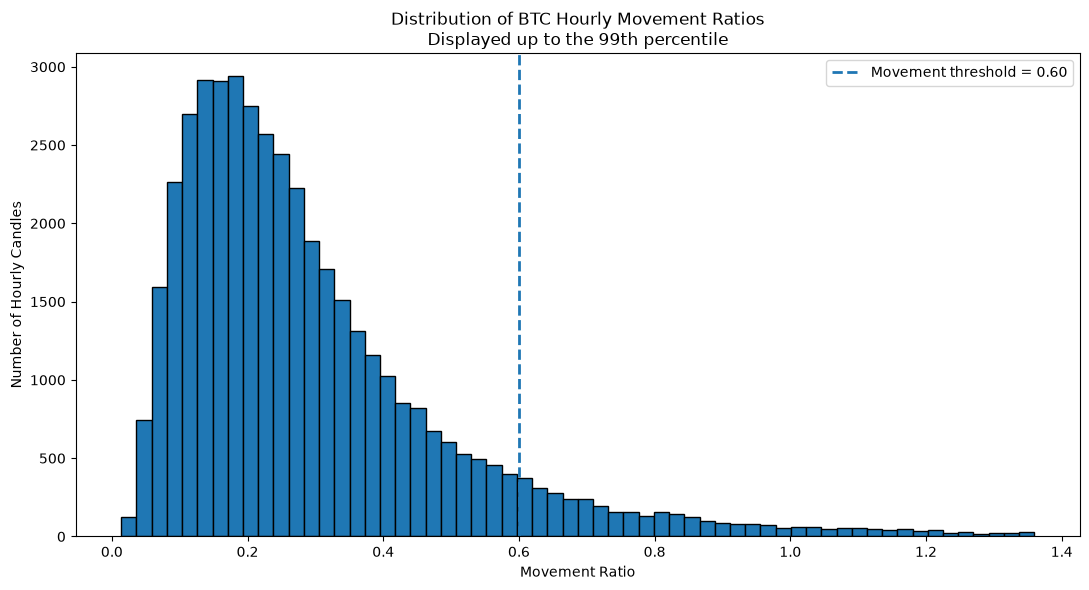


Figure saved to:
C:\projects\project\projectlevel1\reports\figures\movement_ratio_distribution.png


In [4]:
from IPython.display import display


movement_summary = (
    analysis_df["movement_ratio"]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)

movement_event_count = int(
    analysis_df["movement_event"].sum()
)

non_event_count = int(
    (
        analysis_df["movement_event"] == 0
    ).sum()
)

movement_event_rate = float(
    analysis_df["movement_event"].mean()
)

movement_skewness = float(
    analysis_df["movement_ratio"].skew()
)

print("MOVEMENT-RATIO SUMMARY")

print(
    movement_summary.round(6).to_string()
)

print(
    f"\nSkewness: "
    f"{movement_skewness:.4f}"
)

print(
    f"\nMovement events: "
    f"{movement_event_count:,}"
)

print(
    f"Non-movement observations: "
    f"{non_event_count:,}"
)

print(
    f"Movement-event rate: "
    f"{movement_event_rate * 100:.2f}%"
)


plot_limit = float(
    analysis_df["movement_ratio"]
    .quantile(0.99)
)

figure, axis = plt.subplots(
    figsize=(11, 6)
)

axis.hist(
    analysis_df.loc[
        analysis_df["movement_ratio"] <= plot_limit,
        "movement_ratio",
    ],
    bins=60,
    edgecolor="black",
)

axis.axvline(
    0.60,
    linestyle="--",
    linewidth=2,
    label="Movement threshold = 0.60",
)

axis.set_title(
    "Distribution of BTC Hourly Movement Ratios\n"
    "Displayed up to the 99th percentile"
)

axis.set_xlabel("Movement Ratio")
axis.set_ylabel("Number of Hourly Candles")

axis.legend()

figure.tight_layout()

MOVEMENT_DISTRIBUTION_FIGURE = (
    FIGURE_FOLDER
    / "movement_ratio_distribution.png"
)

FIGURE_FOLDER.mkdir(
    parents=True,
    exist_ok=True,
)

figure.savefig(
    MOVEMENT_DISTRIBUTION_FIGURE,
    dpi=200,
)

display(figure)

plt.close(figure)

print(
    f"\nFigure saved to:\n"
    f"{MOVEMENT_DISTRIBUTION_FIGURE}"
)

## Movement Events by UTC Hour

The research question is evaluated by calculating the movement-event rate separately for each UTC hour.

\[
\text{Hourly Event Rate} =
\frac{\text{Movement Events at the Hour}}
{\text{Valid Observations at the Hour}}
\]

Event rate is used instead of raw event count because each hour must be compared relative to its number of available observations.

HOURLY MOVEMENT-EVENT SUMMARY


,utc_hour,observations,movement_events,event_rate_percent,median_movement_ratio,mean_movement_ratio,p90_movement_ratio,event_rate_rank
0,0,1820,180,9.8901,0.2597,0.3310,0.5980,8
1,1,1821,152,8.3471,0.2379,0.3059,0.5521,12
2,2,1819,122,6.7070,0.2098,0.2729,0.4962,15
3,3,1818,80,4.4004,0.1822,0.2353,0.4269,20
4,4,1818,62,3.4103,0.1823,0.2241,0.4045,23
5,5,1819,49,2.6938,0.1795,0.2176,0.3973,24
6,6,1819,69,3.7933,0.1884,0.2304,0.4200,22
7,7,1818,79,4.3454,0.1958,0.2464,0.4532,21
8,8,1818,101,5.5556,0.2206,0.2712,0.4831,17
9,9,1818,114,6.2706,0.2063,0.2676,0.5090,16



Highest event-rate hour:
14:00 UTC
Event rate: 25.52%

Lowest event-rate hour:
05:00 UTC
Event rate: 2.69%

Difference between highest and lowest:
22.83 percentage points

Overall event rate:
9.16%


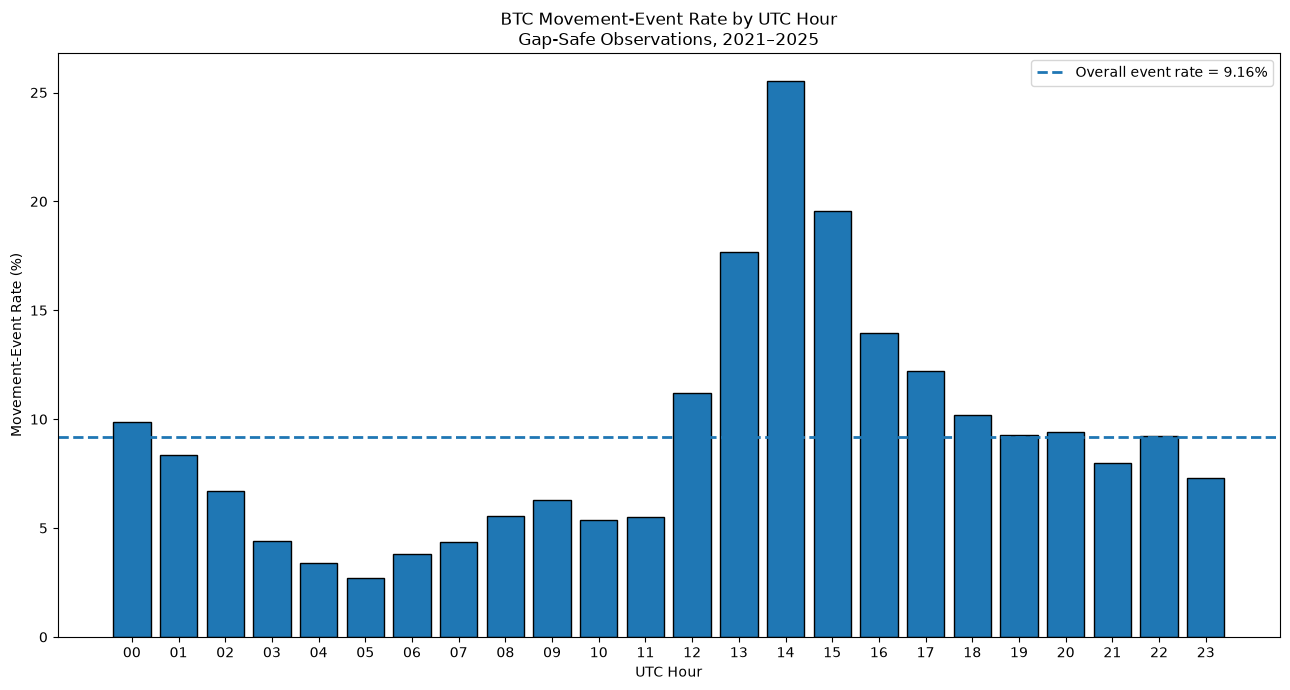


Hourly summary saved to:
C:\projects\project\projectlevel1\reports\hourly_movement_summary.csv

Figure saved to:
C:\projects\project\projectlevel1\reports\figures\movement_event_rate_by_utc_hour.png


In [5]:
from IPython.display import display


hourly_summary = (
    analysis_df
    .groupby("utc_hour")
    .agg(
        observations=(
            "movement_event",
            "size",
        ),
        movement_events=(
            "movement_event",
            "sum",
        ),
        event_rate=(
            "movement_event",
            "mean",
        ),
        median_movement_ratio=(
            "movement_ratio",
            "median",
        ),
        mean_movement_ratio=(
            "movement_ratio",
            "mean",
        ),
        p90_movement_ratio=(
            "movement_ratio",
            lambda series: series.quantile(0.90),
        ),
    )
    .reset_index()
)


hourly_summary["event_rate_percent"] = (
    hourly_summary["event_rate"]
    * 100
)

hourly_summary["event_rate_rank"] = (
    hourly_summary["event_rate"]
    .rank(
        method="min",
        ascending=False,
    )
    .astype(int)
)

hourly_summary = hourly_summary.sort_values(
    "utc_hour"
).reset_index(drop=True)


highest_rate_row = hourly_summary.loc[
    hourly_summary[
        "event_rate_percent"
    ].idxmax()
]

lowest_rate_row = hourly_summary.loc[
    hourly_summary[
        "event_rate_percent"
    ].idxmin()
]

overall_event_rate_percent = (
    analysis_df["movement_event"].mean()
    * 100
)

rate_difference = (
    highest_rate_row["event_rate_percent"]
    - lowest_rate_row["event_rate_percent"]
)


print("HOURLY MOVEMENT-EVENT SUMMARY")

display_columns = [
    "utc_hour",
    "observations",
    "movement_events",
    "event_rate_percent",
    "median_movement_ratio",
    "mean_movement_ratio",
    "p90_movement_ratio",
    "event_rate_rank",
]

display_hourly_summary = hourly_summary[
    display_columns
].copy()

decimal_columns = [
    "event_rate_percent",
    "median_movement_ratio",
    "mean_movement_ratio",
    "p90_movement_ratio",
]

display_hourly_summary[decimal_columns] = (
    display_hourly_summary[decimal_columns]
    .round(4)
)

display(
    display_hourly_summary
)


print(
    "\nHighest event-rate hour:"
)

print(
    f"{int(highest_rate_row['utc_hour']):02d}:00 UTC"
)

print(
    f"Event rate: "
    f"{highest_rate_row['event_rate_percent']:.2f}%"
)


print(
    "\nLowest event-rate hour:"
)

print(
    f"{int(lowest_rate_row['utc_hour']):02d}:00 UTC"
)

print(
    f"Event rate: "
    f"{lowest_rate_row['event_rate_percent']:.2f}%"
)


print(
    "\nDifference between highest and lowest:"
)

print(
    f"{rate_difference:.2f} percentage points"
)


print(
    "\nOverall event rate:"
)

print(
    f"{overall_event_rate_percent:.2f}%"
)


HOURLY_SUMMARY_FILE = (
    REPORT_FOLDER
    / "hourly_movement_summary.csv"
)

hourly_summary.to_csv(
    HOURLY_SUMMARY_FILE,
    index=False,
)


figure, axis = plt.subplots(
    figsize=(13, 7)
)

axis.bar(
    hourly_summary["utc_hour"],
    hourly_summary["event_rate_percent"],
    edgecolor="black",
)

axis.axhline(
    overall_event_rate_percent,
    linestyle="--",
    linewidth=2,
    label=(
        f"Overall event rate = "
        f"{overall_event_rate_percent:.2f}%"
    ),
)

axis.set_title(
    "BTC Movement-Event Rate by UTC Hour\n"
    "Gap-Safe Observations, 2021–2025"
)

axis.set_xlabel("UTC Hour")
axis.set_ylabel("Movement-Event Rate (%)")

axis.set_xticks(
    range(24)
)

axis.set_xticklabels(
    [
        f"{hour:02d}"
        for hour in range(24)
    ]
)

axis.legend()

figure.tight_layout()


HOURLY_EVENT_RATE_FIGURE = (
    FIGURE_FOLDER
    / "movement_event_rate_by_utc_hour.png"
)

figure.savefig(
    HOURLY_EVENT_RATE_FIGURE,
    dpi=200,
)

display(figure)

plt.close(figure)


print(
    f"\nHourly summary saved to:\n"
    f"{HOURLY_SUMMARY_FILE}"
)

print(
    f"\nFigure saved to:\n"
    f"{HOURLY_EVENT_RATE_FIGURE}"
)

## Yearly Stability of the Hourly Pattern

The full-period result may hide changes between years. Therefore, movement-event rates are calculated separately for every combination of year and UTC hour.

This analysis checks:

- whether the highest-risk hours remain similar across years,
- whether the low-risk period remains similar,
- and whether the strength of the hourly pattern changes over time.

YEARLY STABILITY SUMMARY


,year,highest_rate_hour,highest_event_rate_percent,lowest_rate_hour,lowest_event_rate_percent,highest_lowest_difference_pp
0,2021,00:00,12.78,05:00,3.90,8.88
1,2022,14:00,23.84,03:00,3.56,20.27
2,2023,14:00,29.40,04:00,2.75,26.65
3,2024,14:00,31.42,05:00,1.09,30.33
4,2025,14:00,31.23,05:00,1.10,30.14


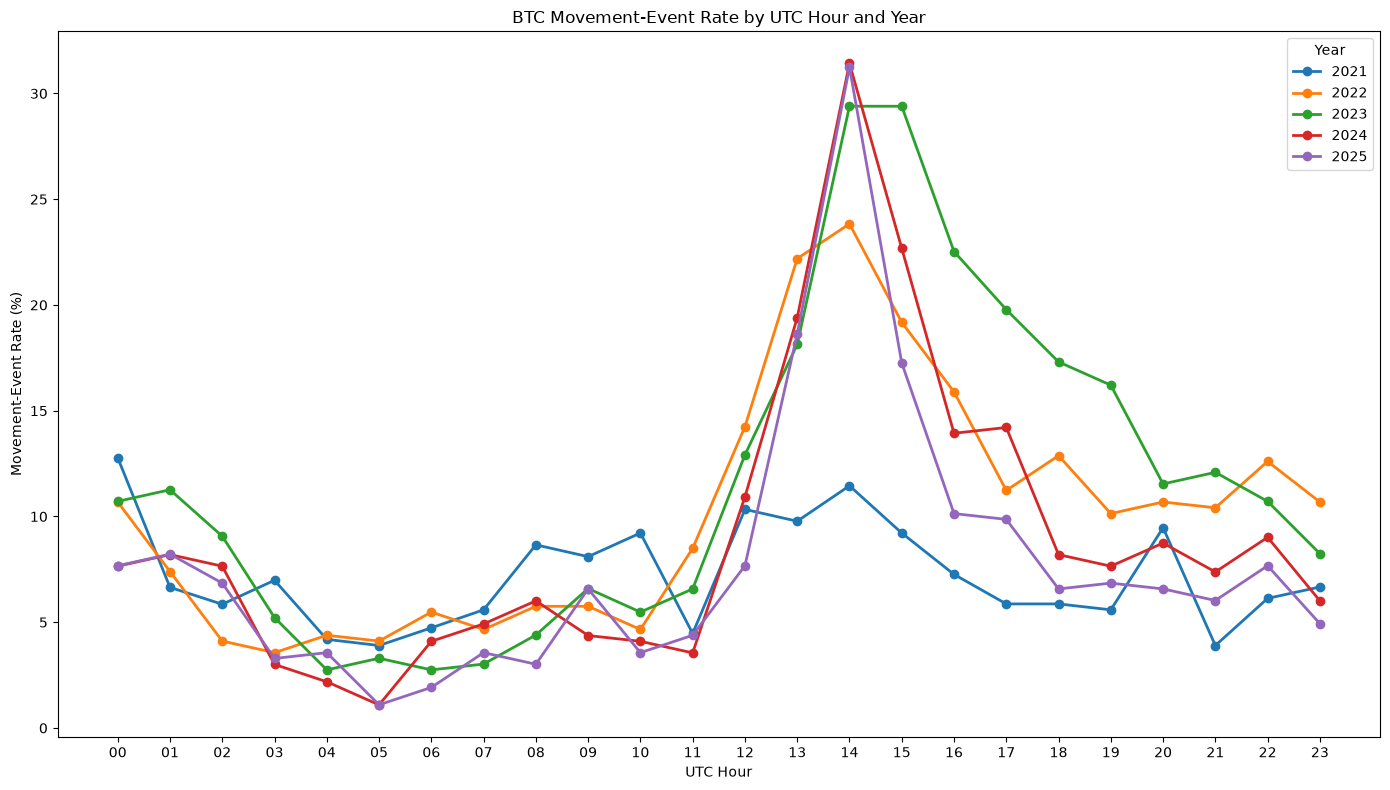


Year-hour summary saved to:
C:\projects\project\projectlevel1\reports\year_hour_movement_summary.csv

Yearly stability summary saved to:
C:\projects\project\projectlevel1\reports\yearly_stability_summary.csv

Figure saved to:
C:\projects\project\projectlevel1\reports\figures\movement_event_rate_by_hour_and_year.png


In [6]:
year_hour_summary = (
    analysis_df
    .groupby(
        [
            "year",
            "utc_hour",
        ]
    )
    .agg(
        observations=(
            "movement_event",
            "size",
        ),
        movement_events=(
            "movement_event",
            "sum",
        ),
        event_rate=(
            "movement_event",
            "mean",
        ),
    )
    .reset_index()
)

year_hour_summary[
    "event_rate_percent"
] = (
    year_hour_summary["event_rate"]
    * 100
)

year_hour_summary = (
    year_hour_summary
    .sort_values(
        [
            "year",
            "utc_hour",
        ]
    )
    .reset_index(drop=True)
)


yearly_peak_rows = (
    year_hour_summary.loc[
        year_hour_summary
        .groupby("year")[
            "event_rate_percent"
        ]
        .idxmax()
    ]
    .copy()
)

yearly_peak_rows = (
    yearly_peak_rows
    .rename(
        columns={
            "utc_hour": "highest_rate_hour",
            "event_rate_percent": (
                "highest_event_rate_percent"
            ),
        }
    )
)


yearly_low_rows = (
    year_hour_summary.loc[
        year_hour_summary
        .groupby("year")[
            "event_rate_percent"
        ]
        .idxmin()
    ]
    .copy()
)

yearly_low_rows = (
    yearly_low_rows
    .rename(
        columns={
            "utc_hour": "lowest_rate_hour",
            "event_rate_percent": (
                "lowest_event_rate_percent"
            ),
        }
    )
)


yearly_stability_summary = (
    yearly_peak_rows[
        [
            "year",
            "highest_rate_hour",
            "highest_event_rate_percent",
        ]
    ]
    .merge(
        yearly_low_rows[
            [
                "year",
                "lowest_rate_hour",
                "lowest_event_rate_percent",
            ]
        ],
        on="year",
        how="inner",
    )
)

yearly_stability_summary[
    "highest_lowest_difference_pp"
] = (
    yearly_stability_summary[
        "highest_event_rate_percent"
    ]
    - yearly_stability_summary[
        "lowest_event_rate_percent"
    ]
)


display_yearly_stability = (
    yearly_stability_summary.copy()
)

percentage_columns = [
    "highest_event_rate_percent",
    "lowest_event_rate_percent",
    "highest_lowest_difference_pp",
]

display_yearly_stability[
    percentage_columns
] = (
    display_yearly_stability[
        percentage_columns
    ]
    .round(2)
)

display_yearly_stability[
    "highest_rate_hour"
] = (
    display_yearly_stability[
        "highest_rate_hour"
    ]
    .astype(int)
    .map(
        lambda hour: f"{hour:02d}:00"
    )
)

display_yearly_stability[
    "lowest_rate_hour"
] = (
    display_yearly_stability[
        "lowest_rate_hour"
    ]
    .astype(int)
    .map(
        lambda hour: f"{hour:02d}:00"
    )
)


print("YEARLY STABILITY SUMMARY")

display(
    display_yearly_stability
)


YEAR_HOUR_SUMMARY_FILE = (
    REPORT_FOLDER
    / "year_hour_movement_summary.csv"
)

YEARLY_STABILITY_FILE = (
    REPORT_FOLDER
    / "yearly_stability_summary.csv"
)

year_hour_summary.to_csv(
    YEAR_HOUR_SUMMARY_FILE,
    index=False,
)

yearly_stability_summary.to_csv(
    YEARLY_STABILITY_FILE,
    index=False,
)


figure, axis = plt.subplots(
    figsize=(14, 8)
)

for year in sorted(
    year_hour_summary["year"].unique()
):
    year_data = year_hour_summary.loc[
        year_hour_summary["year"] == year
    ]

    axis.plot(
        year_data["utc_hour"],
        year_data["event_rate_percent"],
        marker="o",
        linewidth=2,
        label=str(year),
    )

axis.set_title(
    "BTC Movement-Event Rate by UTC Hour and Year"
)

axis.set_xlabel("UTC Hour")
axis.set_ylabel("Movement-Event Rate (%)")

axis.set_xticks(
    range(24)
)

axis.set_xticklabels(
    [
        f"{hour:02d}"
        for hour in range(24)
    ]
)

axis.legend(
    title="Year"
)

figure.tight_layout()


YEARLY_STABILITY_FIGURE = (
    FIGURE_FOLDER
    / "movement_event_rate_by_hour_and_year.png"
)

figure.savefig(
    YEARLY_STABILITY_FIGURE,
    dpi=200,
)

display(figure)

plt.close(figure)


print(
    f"\nYear-hour summary saved to:\n"
    f"{YEAR_HOUR_SUMMARY_FILE}"
)

print(
    f"\nYearly stability summary saved to:\n"
    f"{YEARLY_STABILITY_FILE}"
)

print(
    f"\nFigure saved to:\n"
    f"{YEARLY_STABILITY_FIGURE}"
)

## Baseline, Logistic Regression, and Time-Based Validation

The data is divided chronologically:

- Training period: 2021–2024
- Test period: 2025

The baseline predicts the most common training class for every test candle.

A logistic-regression model uses UTC hour as a categorical input. The model is evaluated in two ways:

1. Binary classification at the standard 50% threshold.
2. Prediction of movement-event rates for each UTC hour.

Because movement events are uncommon, classification accuracy alone may be misleading.

TIME-BASED SPLIT
Training rows: 34,887
Test rows: 8,760
Training period: 2021-01-01 20:00:00+00:00 to 2024-12-31 23:00:00+00:00
Test period: 2025-01-01 00:00:00+00:00 to 2025-12-31 23:00:00+00:00

CLASSIFICATION SUMMARY


,metric,value
0,Baseline accuracy (%),92.2032
1,Logistic accuracy (%),92.2032
2,Baseline predicted events,0.0000
3,Logistic predicted events,0.0000
4,Actual movement events,683.0000



BASELINE CONFUSION MATRIX


,Predicted 0,Predicted 1
Actual 0,8077,0
Actual 1,683,0



LOGISTIC CONFUSION MATRIX


...


HOURLY PROBABILITY VALIDATION


,utc_hour,test_observations,actual_event_rate_percent,model_probability_percent,baseline_probability_percent
0,0,365,7.6712,10.4991,9.5021
1,1,365,8.2192,8.4099,9.5021
2,2,365,6.8493,6.6567,9.5021
3,3,365,3.2877,4.6900,9.5021
4,4,365,3.5616,3.5319,9.5021
5,5,365,1.0959,3.3058,9.5021
6,6,365,1.9178,4.3060,9.5021
7,7,365,3.5616,4.5616,9.5021
8,8,365,3.0137,6.1719,9.5021
9,9,365,6.5753,6.1719,9.5021



PROBABILITY METRICS


,metric,value
0,Model MAE (percentage points),2.4875
1,Baseline MAE (percentage points),5.0064
2,Model RMSE (percentage points),2.9927
3,Baseline RMSE (percentage points),6.5881
4,Model-actual correlation,0.9302



Model highest-risk hour: 14:00 UTC
Actual 2025 highest-risk hour: 14:00 UTC


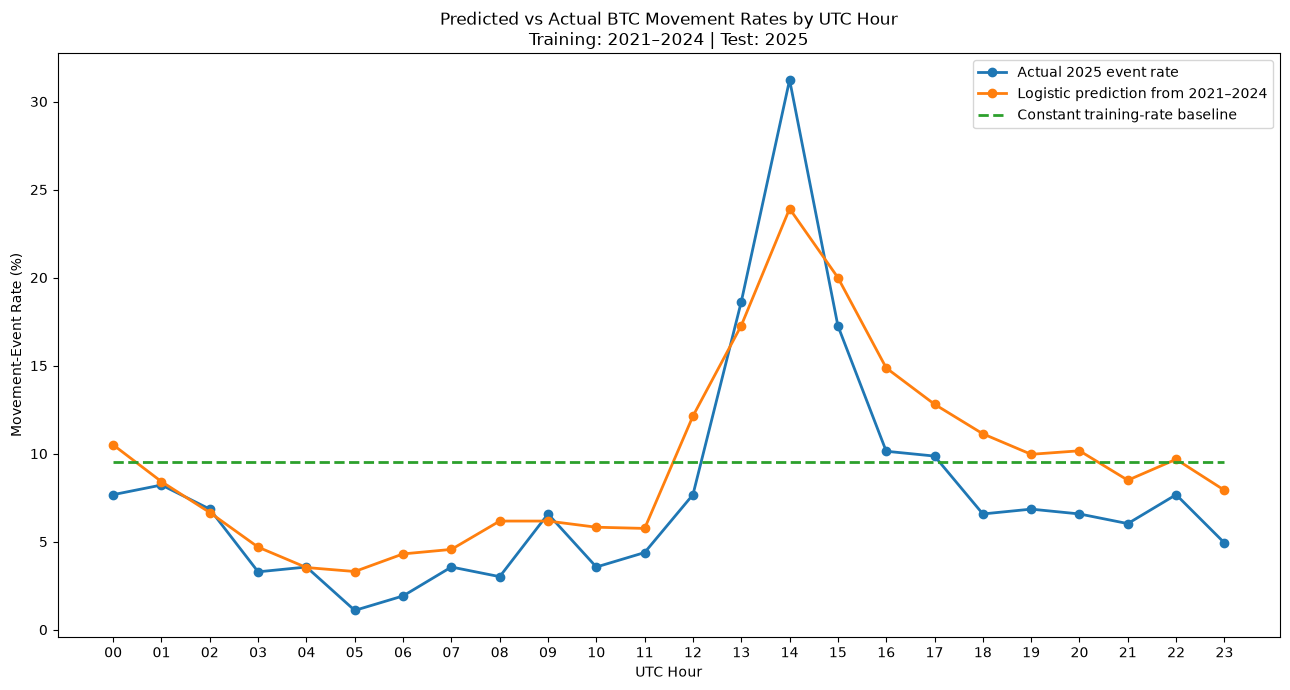


Figure saved to:
C:\projects\project\projectlevel1\reports\figures\notebook_predicted_vs_actual_2025.png


In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


# ============================================================
# TIME-BASED TRAIN-TEST SPLIT
# ============================================================

train_df = analysis_df.loc[
    analysis_df["year"] <= 2024
].copy()

test_df = analysis_df.loc[
    analysis_df["year"] == 2025
].copy()


X_train = train_df[
    [
        "utc_hour",
    ]
]

y_train = train_df[
    "movement_event"
]

X_test = test_df[
    [
        "utc_hour",
    ]
]

y_test = test_df[
    "movement_event"
]


print("TIME-BASED SPLIT")

print(
    f"Training rows: {len(train_df):,}"
)

print(
    f"Test rows: {len(test_df):,}"
)

print(
    f"Training period: "
    f"{train_df['open_time'].min()} "
    f"to {train_df['open_time'].max()}"
)

print(
    f"Test period: "
    f"{test_df['open_time'].min()} "
    f"to {test_df['open_time'].max()}"
)


# ============================================================
# MAJORITY-CLASS BASELINE
# ============================================================

baseline_class = int(
    y_train.mode().iloc[0]
)

baseline_predictions = np.full(
    shape=len(y_test),
    fill_value=baseline_class,
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions,
)

baseline_matrix = confusion_matrix(
    y_test,
    baseline_predictions,
    labels=[
        0,
        1,
    ],
)


# ============================================================
# LOGISTIC REGRESSION
# ============================================================

logistic_model = Pipeline(
    steps=[
        (
            "hour_encoder",
            OneHotEncoder(
                handle_unknown="ignore",
            ),
        ),
        (
            "logistic_regression",
            LogisticRegression(
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)

logistic_model.fit(
    X_train,
    y_train,
)


test_probabilities = (
    logistic_model
    .predict_proba(X_test)[:, 1]
)

test_predictions = (
    test_probabilities >= 0.50
).astype(int)


model_accuracy = accuracy_score(
    y_test,
    test_predictions,
)

model_matrix = confusion_matrix(
    y_test,
    test_predictions,
    labels=[
        0,
        1,
    ],
)


classification_summary = pd.DataFrame(
    {
        "metric": [
            "Baseline accuracy (%)",
            "Logistic accuracy (%)",
            "Baseline predicted events",
            "Logistic predicted events",
            "Actual movement events",
        ],
        "value": [
            baseline_accuracy * 100,
            model_accuracy * 100,
            int(baseline_predictions.sum()),
            int(test_predictions.sum()),
            int(y_test.sum()),
        ],
    }
)


print("\nCLASSIFICATION SUMMARY")

display(
    classification_summary.round(4)
)


print("\nBASELINE CONFUSION MATRIX")

display(
    pd.DataFrame(
        baseline_matrix,
        index=[
            "Actual 0",
            "Actual 1",
        ],
        columns=[
            "Predicted 0",
            "Predicted 1",
        ],
    )
)


print("\nLOGISTIC CONFUSION MATRIX")

display(
    pd.DataFrame(
        model_matrix,
        index=[
            "Actual 0",
            "Actual 1",
        ],
        columns=[
            "Predicted 0",
            "Predicted 1",
        ],
    )
)


# ============================================================
# HOURLY PROBABILITY VALIDATION
# ============================================================

hour_input = pd.DataFrame(
    {
        "utc_hour": range(24),
    }
)

hour_input[
    "model_probability"
] = (
    logistic_model
    .predict_proba(
        hour_input[
            [
                "utc_hour",
            ]
        ]
    )[:, 1]
)


actual_2025_rates = (
    test_df
    .groupby("utc_hour")
    .agg(
        test_observations=(
            "movement_event",
            "size",
        ),
        actual_events=(
            "movement_event",
            "sum",
        ),
        actual_event_rate=(
            "movement_event",
            "mean",
        ),
    )
    .reset_index()
)


validation_df = actual_2025_rates.merge(
    hour_input,
    on="utc_hour",
    how="inner",
)


baseline_probability = float(
    y_train.mean()
)

validation_df[
    "baseline_probability"
] = baseline_probability


validation_df[
    "actual_event_rate_percent"
] = (
    validation_df["actual_event_rate"]
    * 100
)

validation_df[
    "model_probability_percent"
] = (
    validation_df["model_probability"]
    * 100
)

validation_df[
    "baseline_probability_percent"
] = (
    validation_df["baseline_probability"]
    * 100
)


model_mae = mean_absolute_error(
    validation_df[
        "actual_event_rate_percent"
    ],
    validation_df[
        "model_probability_percent"
    ],
)

baseline_mae = mean_absolute_error(
    validation_df[
        "actual_event_rate_percent"
    ],
    validation_df[
        "baseline_probability_percent"
    ],
)

model_rmse = np.sqrt(
    mean_squared_error(
        validation_df[
            "actual_event_rate_percent"
        ],
        validation_df[
            "model_probability_percent"
        ],
    )
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        validation_df[
            "actual_event_rate_percent"
        ],
        validation_df[
            "baseline_probability_percent"
        ],
    )
)

model_actual_correlation = (
    validation_df[
        "actual_event_rate_percent"
    ]
    .corr(
        validation_df[
            "model_probability_percent"
        ]
    )
)


probability_metrics = pd.DataFrame(
    {
        "metric": [
            "Model MAE (percentage points)",
            "Baseline MAE (percentage points)",
            "Model RMSE (percentage points)",
            "Baseline RMSE (percentage points)",
            "Model-actual correlation",
        ],
        "value": [
            model_mae,
            baseline_mae,
            model_rmse,
            baseline_rmse,
            model_actual_correlation,
        ],
    }
)


print("\nHOURLY PROBABILITY VALIDATION")

display(
    validation_df[
        [
            "utc_hour",
            "test_observations",
            "actual_event_rate_percent",
            "model_probability_percent",
            "baseline_probability_percent",
        ]
    ].round(4)
)


print("\nPROBABILITY METRICS")

display(
    probability_metrics.round(4)
)


model_highest_hour = int(
    validation_df.loc[
        validation_df[
            "model_probability_percent"
        ].idxmax(),
        "utc_hour",
    ]
)

actual_highest_hour = int(
    validation_df.loc[
        validation_df[
            "actual_event_rate_percent"
        ].idxmax(),
        "utc_hour",
    ]
)


print(
    f"\nModel highest-risk hour: "
    f"{model_highest_hour:02d}:00 UTC"
)

print(
    f"Actual 2025 highest-risk hour: "
    f"{actual_highest_hour:02d}:00 UTC"
)


# ============================================================
# VALIDATION FIGURE
# ============================================================

figure, axis = plt.subplots(
    figsize=(13, 7)
)

axis.plot(
    validation_df["utc_hour"],
    validation_df[
        "actual_event_rate_percent"
    ],
    marker="o",
    linewidth=2,
    label="Actual 2025 event rate",
)

axis.plot(
    validation_df["utc_hour"],
    validation_df[
        "model_probability_percent"
    ],
    marker="o",
    linewidth=2,
    label="Logistic prediction from 2021–2024",
)

axis.plot(
    validation_df["utc_hour"],
    validation_df[
        "baseline_probability_percent"
    ],
    linestyle="--",
    linewidth=2,
    label="Constant training-rate baseline",
)

axis.set_title(
    "Predicted vs Actual BTC Movement Rates by UTC Hour\n"
    "Training: 2021–2024 | Test: 2025"
)

axis.set_xlabel("UTC Hour")
axis.set_ylabel("Movement-Event Rate (%)")

axis.set_xticks(
    range(24)
)

axis.set_xticklabels(
    [
        f"{hour:02d}"
        for hour in range(24)
    ]
)

axis.legend()

figure.tight_layout()


NOTEBOOK_VALIDATION_FIGURE = (
    FIGURE_FOLDER
    / "notebook_predicted_vs_actual_2025.png"
)

figure.savefig(
    NOTEBOOK_VALIDATION_FIGURE,
    dpi=200,
)

display(figure)

plt.close(figure)


print(
    f"\nFigure saved to:\n"
    f"{NOTEBOOK_VALIDATION_FIGURE}"
)

## Final Interpretation

### Main Finding

BTCUSDT movement events were not distributed evenly across UTC hours during 2021–2025.

A movement event was defined as an hourly candle range equal to at least 60% of the previous candle's Bollinger Band width.

Across all gap-safe observations:

- The overall movement-event rate was **9.16%**.
- The highest event rate occurred at **14:00 UTC**, with **25.52%**.
- The lowest event rate occurred at **05:00 UTC**, with **2.69%**.
- Movement rates were generally elevated between **13:00 and 16:00 UTC**.
- Movement rates were generally low between **03:00 and 07:00 UTC**.

The difference between the highest-rate and lowest-rate hours was approximately **22.83 percentage points**.

### Stability Over Time

The hourly pattern was not equally strong in every year.

The year 2021 showed a weaker and somewhat different pattern. However, **14:00 UTC was the highest-rate hour in 2022, 2023, 2024, and 2025**.

This indicates that the main pattern persisted across several years, although its strength changed over time.

### Model Result

The logistic-regression model used only UTC hour as an input.

At the standard 50% classification threshold, the model predicted no movement events. Its classification accuracy was therefore identical to the majority-class baseline:

- Baseline accuracy: **92.20%**
- Logistic-regression accuracy: **92.20%**
- Correctly detected movement events: **0**

This happened because even the highest predicted hourly movement probability remained below 50%.

However, the model was useful for estimating relative hourly risk.

When trained on 2021–2024 and tested on 2025:

- Model MAE: **2.49 percentage points**
- Baseline MAE: **5.01 percentage points**
- Model RMSE: **2.99 percentage points**
- Baseline RMSE: **6.59 percentage points**
- Correlation between predicted and actual hourly rates: **0.93**

The model correctly identified **14:00 UTC** as the highest-risk hour in the unseen 2025 data.

### Scientific Conclusion

This project shows that BTC movement events occurred more frequently during some UTC hours than others.

UTC hour contains meaningful information about the historical probability of a movement event. However, UTC hour alone is not sufficient to predict whether an individual hourly candle will produce a movement event.

### What the Project Does Not Show

The analysis does not prove that UTC hour causes BTC movements.

It also does not show that trading during the identified hours would be profitable. The project did not analyze:

- movement direction,
- entry or exit rules,
- transaction costs,
- slippage,
- risk management,
- or trading returns.

The observed hourly pattern may be associated with factors such as global trading activity, market-session overlap, scheduled announcements, liquidity, volume, or market regime. These possible explanations were not tested and remain speculative.

### Data Limitations

The dataset contained 14 missing hourly timestamps, and 3 unusable candles were removed.

Gap-affected Bollinger Band observations were excluded from the primary analysis. A sensitivity analysis showed that this treatment changed hourly event rates by less than **0.08 percentage points**, so the missing periods did not materially change the main result.

The findings apply to:

- BTCUSDT,
- one-hour candles,
- the selected Binance data source,
- the 2021–2025 period,
- and the chosen movement-event definition.

Different markets, timeframes, periods, or movement thresholds may produce different results.

### Practical Interpretation

UTC hour may be used as a contextual variable indicating when relatively large BTC movements have historically occurred more frequently.

It should not be used as a standalone trading signal.

### Next Investigation

A later project could test whether prediction improves after adding variables such as:

- trading volume,
- current Bollinger Band width,
- previous candle movement,
- weekday,
- recent volatility,
- trend direction,
- and market regime.